## __Learning objectives__

By the end of this notebook, you should be able to:
* Understand the conceptual structure and functionality of decision trees for regression.
* Train a decision tree model using sklearn.
* Implement recursive binary splitting to partition data effectively.
* Evaluate model performance using mean squared error (MSE).
* Visualise decision tree models.

## __Introduction__

Before we build our first tree, it's important to understand _what_ decision trees are and _how_ they work. Below is a diagram showing the conceptual structure of a decision tree.
#

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://github.com/Explore-AI/Pictures/blob/master/decision_tree_diag.png?raw=true"  style="width:450px";/>
</div>

In simple terms, decision trees are tree-like machine learning models which represent data by partitioning it into different sections based on questions asked of predictive variables in the data.

To make a decision on a new input:

1. We start at the **root node**, which is at the top of an upside-down tree.
2. Ask questions at each **decision node** about the attributes of the input.
3. Repeat 2. until we reach a **terminal node** (also known as a leaf node) at the bottom of the upside-down tree.

Each terminal node in the tree contains a potential output (i.e. $Y$ value) for a given input, $X$. The $Y$ value at a terminal node only becomes the output of our decision tree if the path of decisions on an input $X$ from the root node leads to that particular terminal node.

Consider the following example of a new data point $X$ with a value of 4.5. If we wanted to predict the $Y$ value for this new data point, the path that the input would follow along the decision tree is shown in green below:
#

<div align="center" style=" font-size: 80%; text-align: center; margin: 0 auto">
<img src="https://github.com/Explore-AI/Pictures/blob/master/decision_tree_path.png?raw=true"  style="width:350px";/>
</div>

After following the path highlighted in green, the data point would eventually be assigned a value of $Y = 2$.

So now we know how to _follow_ a decision tree. But where did the values of the split points come from, and how do we know how many `branches` the tree should have?

In the decision process, data points start at the root node and end at a terminal node. The training process follows the same pattern.

In training a decision tree, we begin with all of our training data at the root node and then partition the data into smaller subsets which form the `branches` of the tree.

When partitioning the data, two questions need to be answered:

1. Which predictor variable should be used as the split criterion?

2. What value of the predictor variable should be used as the splitting point?

### **Example 1: Visualise the data**

So now that we have an understanding of how decision trees work, let's implement one using sklearn.

Suppose we are tasked with the problem of predicting the price of a house given its area using a dataset called `house_price_by_area`.

This dataset contains information on the `LotArea` (in square meters) and the corresponding `SalePrice` (in Rands) of properties.

We'll start by importing some commonly used Python libraries and loading our data.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error


In [3]:
file_path = "../data/house_price.csv"
df = pd.read_csv(file_path)

In [4]:
df.head()

,LotArea,SalePrice
0,138,1204000
1,145,1274000
2,152,1673000
3,152,1232000
4,152,1195600


In [7]:
# Independent and dependent variables
X = df["LotArea"]
y = df["SalePrice"]

In [20]:
def style_plot(
    ax,
    title=None,
    xlabel=None,
    ylabel=None,
    figsize=None,
    grid=True,
    remove_spine=True,
    spine_width=1.5,
    label_fontsize=11,
    title_fontsize=13
):
    if figsize:
        ax.figure.set_size_inches(*figsize)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=label_fontsize)

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=label_fontsize)

    if title:
        ax.set_title(title, fontsize=title_fontsize, fontweight="bold")

    if grid:
        ax.grid(alpha=0.3)

    if remove_spine:
        for spine in ax.spines.values():
            spine.set_visible(False)

    return ax

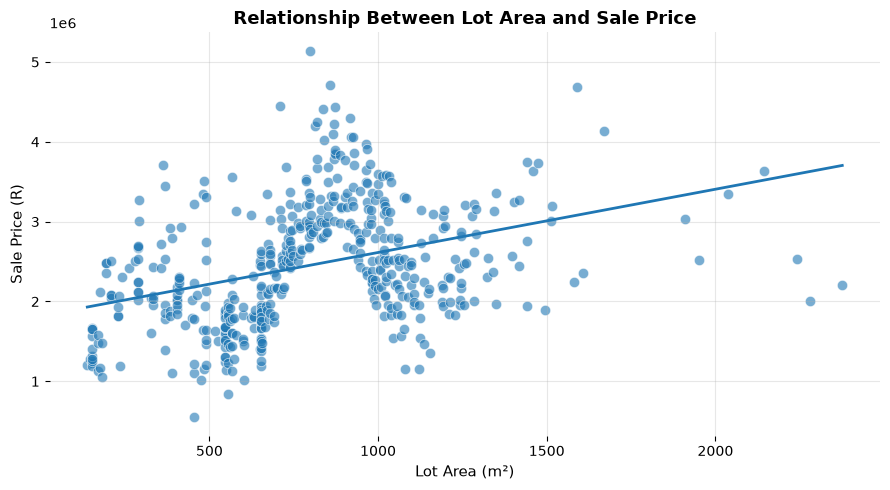

In [28]:
# Create figure and axes
fig, ax = plt.subplots()

# Scatter plot
sns.scatterplot(
    x=X,
    y=y,
    alpha=0.6,
    s=55,
    ax=ax
)

# Add regression trend line
sns.regplot(
    x=X,
    y=y,
    scatter=False,
    ci=None,
    line_kws={"linewidth": 2},
    ax=ax
)

# Title
style_plot(
    ax,
    title = "Relationship Between Lot Area and Sale Price",
    xlabel = "Lot Area (m²)",
    ylabel ="Sale Price (R)",
    grid = True,
    figsize=(9, 5)
)

plt.tight_layout()
plt.show()

### **Example 2: Train-test split**
Next we split our dataset into training and testing sets so that we can later evaluate the performance of the model.

In [12]:
X_reshape = X.values.reshape(-1, 1)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reshape,
    y,
    test_size = 0.2,
    random_state = 42
)

### __Example 3: Building the decision tree__

After importing our Decision Tree Regressor model, we have to instantiate the model. This step also allows us to set model hyperparameters such as:

- **max_depth**: The maximum depth of the tree (i.e. the number of nodes between root and leaf node).
- **criterion**: The function to measure the quality of a split. The model uses the mean squared error (mse) by default.
- **random_state**: A number used to seed the random number generator. Ensures that we get the same tree each time we call model.fit(); among other hyperparameters.

To learn more about other DecisionTreeRegressor hyperparameters and descriptions, run `help(DecisionTreeRegressor)` in a new cell.

In [15]:
# Instantiate regression tree model
tree = DecisionTreeRegressor(max_depth=2,random_state=42)

In [16]:
# Fit the training data
tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

`sklearn` provides a useful feature for visualising a fitted decision tree model. We can access it by importing the `plot_tree` method from the `sklearn.tree` submodule. Take note of the split points for the `LotArea` variable, as well as the MSE values and the number of samples in each subset.

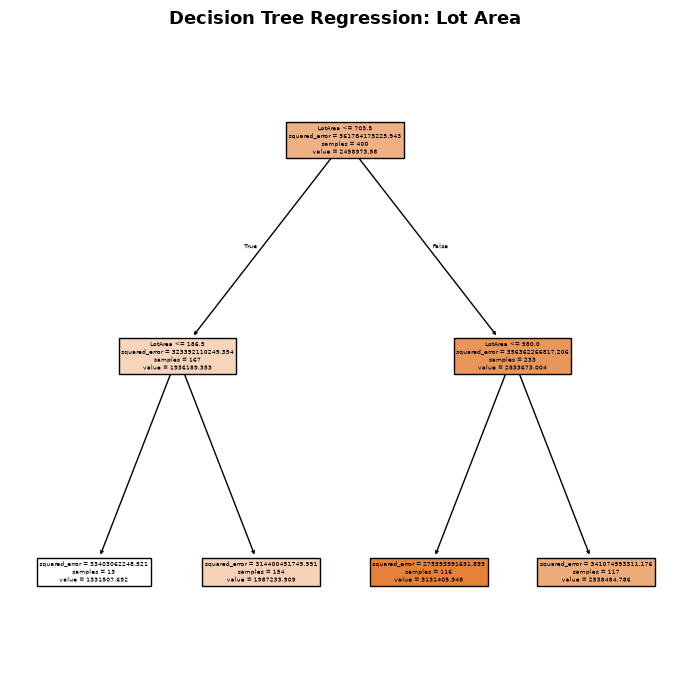

In [25]:
fig, ax = plt.subplots()

plot_tree(
    tree,
    feature_names=["LotArea"],
    filled=True,
    ax=ax
)

style_plot(
    ax,
    title="Decision Tree Regression: Lot Area",
    figsize=(7, 7),
    grid=False
)

plt.tight_layout()
plt.show()

### __Example 4: Evaluating model performance__

We evaluate model performance by comparing the model's predictions on unseen data `(x_test)` with the actual output `(y_test)`. This comparison helps assess how well the model generalises to new data and provides insights into its predictive accuracy. We will use `mean_squared_error` for this.

In [ ]:
y_pred = regr_tree.predict(x_test)

# calculate MSE
MSE = mean_squared_error(y_pred,y_test)

# Report RMSE
print("Regression decision tree model RMSE is:",np.sqrt(MSE))